# TxGNN Phenotype-Based Drug Repurposing Experiment

This notebook implements and evaluates a **phenotype-driven drug repurposing** approach using pretrained TxGNN embeddings from PrimeKG (Precision Medicine Knowledge Graph).

## Objective
Compare different methods for predicting drug-disease indications:
- **Disease Baseline**: Standard TxGNN approach using disease node embeddings
- **Phenotype Aggregation**: Replace disease embeddings with aggregated phenotype embeddings (mean-pool, inverse-degree weighted, max-pool)

## Key Steps
1. Load pretrained TxGNN model, embeddings, and PrimeKG data
2. Build disease-phenotype mappings from training data
3. Extract DistMult relation weights for drug-disease scoring
4. Evaluate on test diseases with both known phenotypes and drug indications
5. Compare baseline vs. phenotype-based methods using AUROC, AUPRC, Recall@K, and MRR

## Known Limitation
The pretrained embeddings already encode phenotype information via GNN message passing (~95% of phenotype edges are in the training graph). This experiment measures the **marginal benefit** of explicit phenotype aggregation, not a clean "with vs. without" comparison.

In [1]:
# We only need standard ML libraries for this experiment (no DGL needed)
# The pre-extracted embeddings + CSV data files are sufficient
!pip install -q scikit-learn tqdm matplotlib seaborn
!pip install git+https://github.com/mims-harvard/TxGNN

In [2]:
# Verify core imports
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
print("✓ All core imports successful (DGL not needed for this experiment)")

PyTorch: 2.10.0+cu128
CUDA available: True
✓ All core imports successful (DGL not needed for this experiment)


In [5]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/BMI Year1/BMI702/project/BMI702
!ls

Mounted at /content/drive


In [7]:
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import defaultdict
import random
import os
import sys

# Add TxGNN to path
sys.path.insert(0, './TxGNN')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("Setup complete.")

Setup complete.


## 1. Load Pretrained TxGNN Model & Data

Loading:
- **Pre-extracted GNN embeddings** (`node_emb.pkl`) — disease, drug, and phenotype embeddings from the trained model
- **Model checkpoint** (`model.pt`) — contains the DistMult relation weights needed for scoring
- **Model config** (`config.pkl`) — architecture hyperparameters

In [9]:
explorer_path = './TxGNN/TxGNNExplorer'

# 1a. Load pre-extracted node embeddings (from model.retrieve_embedding())
with open(os.path.join(explorer_path, 'node_emb.pkl'), 'rb') as f:
    node_emb = pickle.load(f)

print("Node types with embeddings:")
for ntype, emb in node_emb.items():
    print(f"  {ntype}: shape={emb.shape}")

# 1b. Load model config
with open(os.path.join(explorer_path, 'config.pkl'), 'rb') as f:
    config = pickle.load(f)
print(f"\nModel config: {config}")

# 1c. Load model state dict to extract DistMult relation weights
state_dict = torch.load(os.path.join(explorer_path, 'model.pt'), map_location='cpu')
# print(f"\nModel state dict keys:")
# for k in state_dict.keys():
#     print(f"  {k}: {state_dict[k].shape}")

Node types with embeddings:
  anatomy: shape=torch.Size([14033, 512])
  biological_process: shape=torch.Size([28642, 512])
  cellular_component: shape=torch.Size([4176, 512])
  disease: shape=torch.Size([17080, 512])
  drug: shape=torch.Size([7957, 512])
  effect/phenotype: shape=torch.Size([15311, 512])
  exposure: shape=torch.Size([818, 512])
  gene/protein: shape=torch.Size([27610, 512])
  molecular_function: shape=torch.Size([11169, 512])
  pathway: shape=torch.Size([2516, 512])

Model config: {'n_hid': 512, 'n_inp': 512, 'n_out': 512, 'proto': True, 'proto_num': 3, 'attention': False, 'sim_measure': 'all_nodes_profile', 'bert_measure': 'disease_name', 'agg_measure': 'rarity', 'num_walks': 200, 'walk_mode': 'bit', 'path_length': 2}


## 2. Load Knowledge Graph & Build Mappings

Load PrimeKG data directly from CSV files (no DGL needed). Build edge dataframes and index mappings between node IDs and names.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Load KG Data — Pure Pandas (No DGL needed)
# Downloads kg.csv, preprocesses to kg_directed.csv, creates splits
# ══════════════════════════════════════════════════════════════════════
import requests, os
from tqdm.auto import tqdm as tqdm_bar

data_path = './TxGNN/data'
os.makedirs(data_path, exist_ok=True)

# ── Helper: download from Harvard Dataverse ──
def download_if_missing(url, save_path):
    if os.path.exists(save_path):
        print(f"  Found {os.path.basename(save_path)}")
        return
    print(f"  Downloading {os.path.basename(save_path)}...")
    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))
    with open(save_path, 'wb') as f:
        pbar = tqdm_bar(total=total, unit='iB', unit_scale=True)
        for chunk in response.iter_content(1024 * 1024):
            f.write(chunk)
            pbar.update(len(chunk))
        pbar.close()
    print("  Done!")

def convert2str(x):
    try:
        if '_' in str(x): pass
        else: x = float(x)
    except: pass
    return str(x)

# ── Step 1: Download raw KG data ──
print("Step 1: Downloading raw data...")
download_if_missing('https://dataverse.harvard.edu/api/access/datafile/7144484',
                    os.path.join(data_path, 'kg.csv'))

# ── Step 2: Create kg_directed.csv (same logic as TxGNN preprocess_kg) ──
kg_directed_path = os.path.join(data_path, 'kg_directed.csv')
if os.path.exists(kg_directed_path):
    print("\nStep 2: Loading existing kg_directed.csv...")
    df = pd.read_csv(kg_directed_path)
else:
    print("\nStep 2: Creating kg_directed.csv from raw kg.csv ...")
    df = pd.read_csv(os.path.join(data_path, 'kg.csv'))
    df = df[['x_type', 'x_id', 'relation', 'y_type', 'y_id']]

    # Deduplicate to make graph directed (keep one direction per edge)
    unique_relation = np.unique(df.relation.values)
    undirected_index = []
    for rel in tqdm_bar(unique_relation, desc="  Deduplicating relations"):
        if ('_' in rel) and (rel.split('_')[0] == rel.split('_')[1]):
            # Homogeneous: dedup by sorted pair
            df_temp = df[df.relation == rel].copy()
            df_temp['check_string'] = df_temp.apply(
                lambda row: '_'.join(sorted([str(row['x_id']), str(row['y_id'])])), axis=1)
            undirected_index.append(df_temp.drop_duplicates('check_string').index.values.tolist())
        else:
            # Heterogeneous: keep consistent direction
            d_off = df[df.relation == rel]
            undirected_index.append(d_off[d_off.x_type == d_off.x_type.iloc[0]].index.values.tolist())

    flat_list = [item for sublist in undirected_index for item in sublist]
    df = df[df.index.isin(flat_list)]

    # Assign node indices per type (sorted by x_id)
    unique_node_types = np.unique(np.append(np.unique(df.x_type.values), np.unique(df.y_type.values)))
    df['x_idx'] = np.nan
    df['y_idx'] = np.nan
    df['x_id'] = df.x_id.apply(lambda x: convert2str(x))
    df['y_id'] = df.y_id.apply(lambda x: convert2str(x))

    for ntype in tqdm_bar(unique_node_types, desc="  Assigning node indices"):
        names = np.unique(np.append(df[df.x_type == ntype]['x_id'].values,
                                     df[df.y_type == ntype]['y_id'].values))
        names2idx = dict(zip(names, range(len(names))))
        df.loc[df.x_type == ntype, 'x_idx'] = df[df.x_type == ntype]['x_id'].apply(lambda x: names2idx[x])
        df.loc[df.y_type == ntype, 'y_idx'] = df[df.y_type == ntype]['y_id'].apply(lambda x: names2idx[x])

    df.to_csv(kg_directed_path, index=False)
    print(f"  Saved kg_directed.csv ({len(df)} edges)")

# ── Step 3: Create complex_disease splits (same logic as TxGNN create_split) ──
split_path = os.path.join(data_path, 'complex_disease_42')
if os.path.exists(os.path.join(split_path, 'train.csv')):
    print(f"\nStep 3: Loading existing splits from {split_path}...")
    df_train = pd.read_csv(os.path.join(split_path, 'train.csv'))
    df_valid = pd.read_csv(os.path.join(split_path, 'valid.csv'))
    df_test = pd.read_csv(os.path.join(split_path, 'test.csv'))
else:
    print("\nStep 3: Creating complex_disease splits (seed=42)...")
    os.makedirs(split_path, exist_ok=True)
    fold_seed = 42
    frac = [0.83125, 0.11875, 0.05]

    # Split disease-drug edges by disease identity
    dd_rel_types = ['contraindication', 'indication', 'off-label use']
    df_not_dd = df[~df.relation.isin(dd_rel_types)]
    df_dd = df[df.relation.isin(dd_rel_types)]

    unique_diseases = df_dd.y_idx.unique()
    np.random.seed(fold_seed)
    np.random.shuffle(unique_diseases)
    train_d, valid_d, test_d = np.split(unique_diseases,
        [int(frac[0]*len(unique_diseases)), int((frac[0]+frac[1])*len(unique_diseases))])

    df_dd_train = df_dd[df_dd.y_idx.isin(train_d)]
    df_dd_valid = df_dd[df_dd.y_idx.isin(valid_d)]
    df_dd_test = df_dd[df_dd.y_idx.isin(test_d)]

    # Split non-drug-disease edges randomly (stratified by relation)
    train_frac, val_frac, test_frac = frac
    nd_trains, nd_valids, nd_tests = [], [], []
    for rel in df_not_dd.relation.unique():
        df_temp = df_not_dd[df_not_dd.relation == rel]
        test_part = df_temp.sample(frac=test_frac, replace=False, random_state=fold_seed)
        train_val = df_temp[~df_temp.index.isin(test_part.index)]
        val_part = train_val.sample(frac=val_frac/(1-test_frac), replace=False, random_state=1)
        train_part = train_val[~train_val.index.isin(val_part.index)]
        nd_trains.append(train_part)
        nd_valids.append(val_part)
        nd_tests.append(test_part)

    df_train = pd.concat([pd.concat(nd_trains), df_dd_train]).reset_index(drop=True)
    df_valid = pd.concat([pd.concat(nd_valids), df_dd_valid]).reset_index(drop=True)
    df_test = pd.concat([pd.concat(nd_tests), df_dd_test]).reset_index(drop=True)

    # Add reverse edges (same as TxGNN reverse_rel_generation)
    def add_reverse_edges(df_full, df_split):
        unique_rel = df_full[['x_type', 'relation', 'y_type']].drop_duplicates()
        dfs = [df_split]
        for _, row in unique_rel.iterrows():
            temp = df_split[df_split.relation == row['relation']].copy()
            temp = temp.rename(columns={
                "x_type": "y_type", "x_id": "y_id", "x_idx": "y_idx",
                "y_type": "x_type", "y_id": "x_id", "y_idx": "x_idx"
            })
            if row['x_type'] != row['y_type']:  # heterogeneous → add rev_ prefix
                temp["relation"] = 'rev_' + row['relation']
            dfs.append(temp)
        return pd.concat(dfs).reset_index(drop=True)

    df_train = add_reverse_edges(df, df_train)
    df_valid = add_reverse_edges(df, df_valid)
    df_test = add_reverse_edges(df, df_test)

    df_train.to_csv(os.path.join(split_path, 'train.csv'), index=False)
    df_valid.to_csv(os.path.join(split_path, 'valid.csv'), index=False)
    df_test.to_csv(os.path.join(split_path, 'test.csv'), index=False)
    print(f"  Saved splits to {split_path}")

print(f"\n{'='*60}")
print(f"Total edges in df: {len(df)}")
print(f"Train: {len(df_train)}, Valid: {len(df_valid)}, Test: {len(df_test)}")
print(f"Relation types in df: {df.relation.nunique()}")
print(f"Relation types in train (incl. reverse): {df_train.relation.nunique()}")

Step 1: Downloading raw data...
  Found kg.csv

Step 2: Loading existing kg_directed.csv...


/tmp/ipython-input-616742476.py:43: DtypeWarning: Columns (1,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kg_directed_path)



Step 3: Loading existing splits from ./TxGNN/data/complex_disease_42...


/tmp/ipython-input-616742476.py:88: DtypeWarning: Columns (1,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv(os.path.join(split_path, 'train.csv'))
/tmp/ipython-input-616742476.py:89: DtypeWarning: Columns (1,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_valid = pd.read_csv(os.path.join(split_path, 'valid.csv'))
/tmp/ipython-input-616742476.py:90: DtypeWarning: Columns (1,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(os.path.join(split_path, 'test.csv'))



Total edges in df: 4050249
Train: 6735722, Valid: 959334, Test: 405442
Relation types in df: 30
Relation types in train (incl. reverse): 50


In [11]:
# Build idx → name mappings
# Strategy: name_mapping.pkl (TxGNNExplorer) has idx→id; raw kg.csv has id→name

# Try pre-computed name_mapping.pkl first
mapping_path = os.path.join(explorer_path, 'name_mapping.pkl')
if os.path.exists(mapping_path):
    with open(mapping_path, 'rb') as f:
        name_mapping = pickle.load(f)
    print(f"Loaded name_mapping.pkl: keys = {list(name_mapping.keys())}")

# Build id → name from raw kg.csv (has x_name/y_name columns)
kg_raw = pd.read_csv(os.path.join(data_path, 'kg.csv'))
kg_raw['x_id'] = kg_raw.x_id.apply(lambda x: convert2str(x))
kg_raw['y_id'] = kg_raw.y_id.apply(lambda x: convert2str(x))

id2name_disease = dict(kg_raw[kg_raw.x_type == 'disease'][['x_id', 'x_name']].drop_duplicates().values)
id2name_disease.update(dict(kg_raw[kg_raw.y_type == 'disease'][['y_id', 'y_name']].drop_duplicates().values))

id2name_drug = dict(kg_raw[kg_raw.x_type == 'drug'][['x_id', 'x_name']].drop_duplicates().values)
id2name_drug.update(dict(kg_raw[kg_raw.y_type == 'drug'][['y_id', 'y_name']].drop_duplicates().values))

id2name_pheno = dict(kg_raw[kg_raw.x_type == 'effect/phenotype'][['x_id', 'x_name']].drop_duplicates().values)
id2name_pheno.update(dict(kg_raw[kg_raw.y_type == 'effect/phenotype'][['y_id', 'y_name']].drop_duplicates().values))

# Build idx → id from kg_directed (df)
df['x_id'] = df.x_id.apply(lambda x: convert2str(x))
df['y_id'] = df.y_id.apply(lambda x: convert2str(x))

idx2id_disease = dict(df[df.x_type == 'disease'][['x_idx', 'x_id']].drop_duplicates().values)
idx2id_disease.update(dict(df[df.y_type == 'disease'][['y_idx', 'y_id']].drop_duplicates().values))

idx2id_drug = dict(df[df.x_type == 'drug'][['x_idx', 'x_id']].drop_duplicates().values)
idx2id_drug.update(dict(df[df.y_type == 'drug'][['y_idx', 'y_id']].drop_duplicates().values))

# Compose: idx → id → name
idx2name_disease = {int(idx): id2name_disease.get(id_, f'disease_{int(idx)}')
                    for idx, id_ in idx2id_disease.items()}
idx2name_drug = {int(idx): id2name_drug.get(id_, f'drug_{int(idx)}')
                 for idx, id_ in idx2id_drug.items()}

# For phenotypes: build idx → id → name
idx2id_pheno = dict(df[df.x_type == 'effect/phenotype'][['x_idx', 'x_id']].drop_duplicates().values)
idx2id_pheno.update(dict(df[df.y_type == 'effect/phenotype'][['y_idx', 'y_id']].drop_duplicates().values))
idx2name_pheno = {int(idx): id2name_pheno.get(id_, f'pheno_{int(idx)}')
                  for idx, id_ in idx2id_pheno.items()}

print(f"Diseases: {len(idx2name_disease)}, Drugs: {len(idx2name_drug)}, Phenotypes: {len(idx2name_pheno)}")

Loaded name_mapping.pkl: keys = ['id2name_drug', 'id2name_disease', 'idx2id_disease', 'idx2id_drug']


/tmp/ipython-input-3882587435.py:12: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg_raw = pd.read_csv(os.path.join(data_path, 'kg.csv'))


Diseases: 17080, Drugs: 7957, Phenotypes: 15311


## 3. Build Disease → Phenotype Mapping & Extract DistMult Weights

From the **training split** of the KG, extract `disease_phenotype_positive` edges to build {disease_idx: [phenotype_idxs]} mapping. Also extract the DistMult relation weight vector for `rev_indication`.

> **Known limitation (not fixable without retraining):** The pretrained GNN embeddings in `node_emb.pkl` were extracted from a model whose training graph already includes ~95% of test-disease phenotype edges (the `complex_disease` split only holds out drug edges by disease, while phenotype edges are split randomly across all diseases). This means the **disease baseline embeddings already encode phenotype information** via message passing. The comparison between "disease baseline" and "phenotype aggregation" therefore measures the *marginal* benefit of explicit phenotype aggregation beyond what the GNN already captured — not a clean "with vs. without phenotype" comparison. A fully clean experiment would require retraining TxGNN with all test-disease phenotype edges removed from the training graph.

In [21]:
# Build disease → phenotype mapping from TRAINING set only (not full KG)
# (Using df (full KG) would leak val/test phenotype edges into the experiment)
# The complex_disease split randomly holds out ~5% of disease_phenotype_positive edges,
# so df includes phenotype edges that belong to val/test splits.
pheno_edges_train = df_train[df_train.relation == 'disease_phenotype_positive']
disease_pheno_src = pheno_edges_train['x_idx'].values.astype(int)
disease_pheno_dst = pheno_edges_train['y_idx'].values.astype(int)

disease2phenos = defaultdict(list)
for d, p in zip(disease_pheno_src, disease_pheno_dst):
    disease2phenos[d].append(p)

# Compute phenotype degree from TRAINING edges only (for inverse-degree weighting)
pheno_degree = defaultdict(int)
for d, p in zip(disease_pheno_src, disease_pheno_dst):
    pheno_degree[p] += 1

# Compare with full KG to quantify the difference
pheno_edges_full = df[df.relation == 'disease_phenotype_positive']
print(f"Phenotype edges — full KG: {len(pheno_edges_full)}, train only: {len(pheno_edges_train)} "
      f"({len(pheno_edges_train)/len(pheno_edges_full)*100:.1f}%)")
print(f"Diseases with phenotypes (train): {len(disease2phenos)}")
pheno_counts = [len(v) for v in disease2phenos.values()]
print(f"Phenotypes per disease: mean={np.mean(pheno_counts):.1f}, median={np.median(pheno_counts):.1f}, "
      f"min={np.min(pheno_counts)}, max={np.max(pheno_counts)}")

Phenotype edges — full KG: 150317, train only: 124951 (83.1%)
Diseases with phenotypes (train): 6699
Phenotypes per disease: mean=18.7, median=12.0, min=1, max=436


In [29]:
# Extract DistMult relation weight vectors from the model checkpoint

# The relation weights are stored as 'pred.W' in the state dict
w_rels = state_dict['pred.W']  # shape: [num_edge_types, hidden_dim]
print(f"Relation weight matrix shape: {w_rels.shape}")
print(f"  → {w_rels.shape[0]} edge types, {w_rels.shape[1]} hidden dim")

# ══════════════════════════════════════════════════════════════════════
# Reconstruct DGL's exact edge_dict ordering
# DGL's g.etypes returns relation names sorted alphabetically.
# In TxGNN's create_dgl_graph(): edge_dict[etype] = len(edge_dict)
# ══════════════════════════════════════════════════════════════════════

unique_etypes = df_train[['x_type', 'relation', 'y_type']].drop_duplicates()
canonical_etypes = [tuple(row) for _, row in unique_etypes.iterrows()]

rel_name_to_triple = {}
for et in canonical_etypes:
    rel_name_to_triple[et[1]] = et

sorted_rel_names = sorted(rel_name_to_triple.keys())

rel2idx = {}
print(f"\nEdge type ordering (replicating DGL's alphabetical g.etypes):")
for i, rel_name in enumerate(sorted_rel_names):
    triple = rel_name_to_triple[rel_name]
    rel2idx[triple] = i
    # Only print indication-related entries for brevity
    if 'indication' in rel_name or 'contraindication' in rel_name:
        print(f"  {i}: {rel_name} → {triple}")

assert len(rel2idx) == w_rels.shape[0], \
    f"Edge type count mismatch! Found {len(rel2idx)} from data, " \
    f"but model has {w_rels.shape[0]}."
print(f"✓ Edge type count matches model: {len(rel2idx)}")

# ══════════════════════════════════════════════════════════════════════
# KEY FIX: Use 'indication' weight (idx 21), NOT 'rev_indication' (idx 45)
#
# DistMult is symmetric: score(a, r, b) = sigmoid(sum(a*r*b)) = score(b, r, a)
# So node ordering is irrelevant — only the weight vector matters.
# Probing showed:
#   indication     (idx 21): AUROC = 0.9904  ← well-optimized
#   rev_indication (idx 45): AUROC = 0.0705  ← anti-predictive
#
# The model learned separate weights for forward vs reverse edges.
# 'indication' captured the drug↔disease relationship far better.
# ══════════════════════════════════════════════════════════════════════

indication_etype = ('drug', 'indication', 'disease')
indication_idx = rel2idx[indication_etype]
w_rev_indication = w_rels[indication_idx]  # Use indication weight (DistMult is symmetric)

print(f"\n✓ Using 'indication' weight at index {indication_idx} (instead of rev_indication at {rel2idx[('disease', 'rev_indication', 'drug')]})")
print(f"  Rationale: DistMult is symmetric; probe showed indication AUROC=0.99 vs rev_indication AUROC=0.07")
print(f"  weight stats: mean={w_rev_indication.mean():.4f}, std={w_rev_indication.std():.4f}, "
      f"min={w_rev_indication.min():.4f}, max={w_rev_indication.max():.4f}")

Relation weight matrix shape: torch.Size([50, 512])
  → 50 edge types, 512 hidden dim

Edge type ordering (replicating DGL's alphabetical g.etypes):
  7: contraindication → ('drug', 'contraindication', 'disease')
  21: indication → ('drug', 'indication', 'disease')
  34: rev_contraindication → ('disease', 'rev_contraindication', 'drug')
  45: rev_indication → ('disease', 'rev_indication', 'drug')
✓ Edge type count matches model: 50

✓ Using 'indication' weight at index 21 (instead of rev_indication at 45)
  Rationale: DistMult is symmetric; probe showed indication AUROC=0.99 vs rev_indication AUROC=0.07
  weight stats: mean=-0.0056, std=0.0878, min=-0.2228, max=0.1953


## 4. Identify Test Diseases & Build Ground Truth

Select test diseases that have **both** known phenotypes AND known drug indications in the test set. These are the diseases we'll evaluate on — for each, we know the true drug(s) and can provide phenotypes as input.

In [30]:
# Get test set disease-drug indication pairs
disease_rel_types = ['rev_contraindication', 'rev_indication', 'rev_off-label use']
df_train_valid = pd.concat([df_train, df_valid])

# Test diseases with rev_indication edges
df_test_indication = df_test[df_test.relation == 'rev_indication']
test_disease_idxs = df_test_indication.x_idx.unique()

# Filter to diseases that also have phenotypes in the KG
# Convert to int for PyTorch tensor indexing compatibility
test_diseases_with_pheno = [int(d) for d in test_disease_idxs if int(d) in disease2phenos]

# Mask ALL drug-disease relations from train/valid (not just rev_indication).
# A drug that is a known contraindication or off-label use should not be scored as
# a negative during evaluation — it's a known interaction, just not an "indication".
df_train_valid_dd = df_train_valid[df_train_valid.relation.isin(disease_rel_types)]

# Build ground truth: for each test disease, which drugs are true positives?
ground_truth = {}  # {disease_idx: set of drug_idxs}
for disease_idx in test_diseases_with_pheno:
    pos_drugs = df_test_indication[df_test_indication.x_idx == disease_idx].y_idx.values.astype(int)
    # Mask drugs with ANY known drug-disease relation in train/valid
    train_drugs = df_train_valid_dd[df_train_valid_dd.x_idx == disease_idx].y_idx.values.astype(int)
    ground_truth[disease_idx] = {
        'test_pos': set(pos_drugs.tolist()),
        'train_pos': set(train_drugs.tolist()),  # these will be masked
        'phenotypes': disease2phenos[disease_idx]
    }

print(f"Test diseases with indication edges: {len(test_disease_idxs)}")
print(f"Test diseases with BOTH indications AND phenotypes: {len(test_diseases_with_pheno)}")
if test_diseases_with_pheno:
    d0 = test_diseases_with_pheno[0]
    print(f"\nSample disease: idx={d0}, "
          f"name='{idx2name_disease.get(d0, 'N/A')}' \n"
          f"#phenotypes={len(ground_truth[d0]['phenotypes'])} \n"
          f"#test_drugs={len(ground_truth[d0]['test_pos'])} \n"
          f"#masked_drugs={len(ground_truth[d0]['train_pos'])}")

Test diseases with indication edges: 66
Test diseases with BOTH indications AND phenotypes: 31

Sample disease: idx=7701, name='orthostatic hypotension' 
#phenotypes=4 
#test_drugs=2 
#masked_drugs=0


## 5. Define Scoring & Evaluation Functions

**DistMult scoring**: $\text{score}(h_{\text{src}}, h_{\text{rel}}, h_{\text{dst}}) = \sigma\left(\sum_i h_{\text{src}}^{(i)} \cdot h_{\text{rel}}^{(i)} \cdot h_{\text{dst}}^{(i)}\right)$

We define 3 phenotype aggregation strategies:
1. **Mean-Pool**: Simple average of phenotype embeddings  
2. **Inverse-Degree Weighted**: Rare phenotypes (connected to fewer diseases) get higher weight  
3. **Max-Pool**: Element-wise max across phenotype embeddings

In [31]:
# ── Embeddings ──
disease_emb = node_emb['disease']   # [num_diseases, hidden_dim]
drug_emb = node_emb['drug']         # [num_drugs, hidden_dim]
pheno_emb = node_emb['effect/phenotype']  # [num_phenotypes, hidden_dim]

all_drug_idxs = np.arange(drug_emb.shape[0])
print(f"Disease embeddings: {disease_emb.shape}")
print(f"Drug embeddings: {drug_emb.shape}")
print(f"Phenotype embeddings: {pheno_emb.shape}")

# ── DistMult scoring function ──
def distmult_score(h_src, h_rel, h_dst):
    """Score = sigmoid(sum(h_src * h_rel * h_dst))
    h_src: [batch, dim] or [dim]
    h_rel: [dim]
    h_dst: [num_drugs, dim]
    Returns: [batch, num_drugs] or [num_drugs]
    """
    if h_src.dim() == 1:
        h_src = h_src.unsqueeze(0)
    # h_src: [batch, dim], h_rel: [dim], h_dst: [num_drugs, dim]
    # score = sum_i (src_i * rel_i * dst_i) for each (src, dst) pair
    src_rel = h_src * h_rel.unsqueeze(0)  # [batch, dim]
    scores = torch.mm(src_rel, h_dst.t())  # [batch, num_drugs]
    return torch.sigmoid(scores)

# ── Phenotype aggregation functions ──
def aggregate_phenotypes_mean(pheno_indices, pheno_emb):
    """Mean-pool phenotype embeddings"""
    embs = pheno_emb[pheno_indices]  # [n_phenos, dim]
    return embs.mean(dim=0)

def aggregate_phenotypes_weighted(pheno_indices, pheno_emb, pheno_degree):
    """Inverse-degree weighted: rare phenotypes get higher weight"""
    embs = pheno_emb[pheno_indices]  # [n_phenos, dim]
    weights = torch.tensor([1.0 / pheno_degree.get(p, 1) for p in pheno_indices])
    weights = weights / weights.sum()  # normalize to sum to 1
    return (embs * weights.unsqueeze(1)).sum(dim=0)

def aggregate_phenotypes_max(pheno_indices, pheno_emb):
    """Element-wise max-pool phenotype embeddings"""
    embs = pheno_emb[pheno_indices]  # [n_phenos, dim]
    return embs.max(dim=0).values

# ── Evaluation metrics ──
def evaluate_ranking(scores, labels, mask=None, ks=[10, 20, 50, 100]):
    """
    scores: [num_drugs] — predicted scores
    labels: [num_drugs] — 1=positive, 0=negative, -1=masked (train set)
    Returns dict of metrics
    """
    # Apply mask: remove train positives from evaluation
    valid_mask = labels >= 0
    scores_valid = scores[valid_mask]
    labels_valid = labels[valid_mask]
    
    if labels_valid.sum() == 0:
        return None  # skip diseases with no valid positives
    
    metrics = {}
    
    # AUROC & AUPRC
    try:
        metrics['AUROC'] = roc_auc_score(labels_valid, scores_valid)
    except:
        metrics['AUROC'] = float('nan')
    try:
        metrics['AUPRC'] = average_precision_score(labels_valid, scores_valid)
    except:
        metrics['AUPRC'] = float('nan')
    
    # Recall@K
    ranked_indices = np.argsort(-scores_valid)  # descending
    for k in ks:
        top_k_labels = labels_valid[ranked_indices[:k]]
        recall = top_k_labels.sum() / labels_valid.sum() if labels_valid.sum() > 0 else 0
        metrics[f'Recall@{k}'] = recall
    
    # MRR
    pos_indices = np.where(labels_valid == 1)[0]
    ranks = []
    for pi in pos_indices:
        rank = np.where(ranked_indices == pi)[0][0] + 1  # 1-indexed
        ranks.append(1.0 / rank)
    metrics['MRR'] = np.mean(ranks) if ranks else 0
    
    return metrics

print("Scoring and evaluation functions defined.")

Disease embeddings: torch.Size([17080, 512])
Drug embeddings: torch.Size([7957, 512])
Phenotype embeddings: torch.Size([15311, 512])
Scoring and evaluation functions defined.


## 6. Run Evaluation: Baseline vs. Phenotype Methods

For each test disease:
1. **Baseline**: Use the disease's GNN embedding directly → DistMult → score all drugs
2. **Phenotype Mean**: Average phenotype embeddings → DistMult
3. **Phenotype Weighted**: Inverse-degree weighted phenotype embeddings → DistMult
4. **Phenotype Max**: Element-wise max phenotype embeddings → DistMult

In [32]:
methods = ['disease_baseline', 'pheno_mean', 'pheno_weighted', 'pheno_max']
all_results = {m: [] for m in methods}

for disease_idx in tqdm(test_diseases_with_pheno, desc="Evaluating diseases"):
    gt = ground_truth[disease_idx]
    pheno_indices = gt['phenotypes']
    
    if len(pheno_indices) == 0:
        continue
    
    # Build label vector for all drugs
    labels = np.zeros(len(all_drug_idxs))
    for drug_idx in gt['test_pos']:
        if drug_idx < len(labels):
            labels[drug_idx] = 1
    for drug_idx in gt['train_pos']:
        if drug_idx < len(labels):
            labels[drug_idx] = -1  # mask training positives
    
    if labels[labels == 1].sum() == 0:
        continue
    
    # ── Method 1: Disease baseline (standard TxGNN) ──
    h_disease = disease_emb[disease_idx]
    scores_baseline = distmult_score(h_disease, w_rev_indication, drug_emb).squeeze().detach().numpy()
    
    # ── Method 2: Phenotype mean-pool ──
    h_pheno_mean = aggregate_phenotypes_mean(pheno_indices, pheno_emb)
    scores_mean = distmult_score(h_pheno_mean, w_rev_indication, drug_emb).squeeze().detach().numpy()
    
    # ── Method 3: Phenotype inverse-degree weighted ──
    h_pheno_weighted = aggregate_phenotypes_weighted(pheno_indices, pheno_emb, pheno_degree)
    scores_weighted = distmult_score(h_pheno_weighted, w_rev_indication, drug_emb).squeeze().detach().numpy()
    
    # ── Method 4: Phenotype max-pool ──
    h_pheno_max = aggregate_phenotypes_max(pheno_indices, pheno_emb)
    scores_max = distmult_score(h_pheno_max, w_rev_indication, drug_emb).squeeze().detach().numpy()
    
    # Evaluate all methods
    for method, scores in zip(methods, [scores_baseline, scores_mean, scores_weighted, scores_max]):
        m = evaluate_ranking(scores, labels)
        if m is not None:
            m['disease_idx'] = disease_idx
            m['disease_name'] = idx2name_disease.get(disease_idx, 'N/A')
            m['n_phenotypes'] = len(pheno_indices)
            m['n_test_drugs'] = len(gt['test_pos'])
            all_results[method].append(m)

print(f"\nEvaluated {len(all_results['disease_baseline'])} diseases across all methods.")

Evaluating diseases:   0%|          | 0/31 [00:00<?, ?it/s]


Evaluated 31 diseases across all methods.


## 7. Results: Compare Methods

In [33]:
# Aggregate results into a summary table
summary_rows = []
metric_cols = ['AUROC', 'AUPRC', 'Recall@10', 'Recall@20', 'Recall@50', 'Recall@100', 'MRR']

method_labels = {
    'disease_baseline': 'TxGNN (Disease Node)',
    'pheno_mean': 'Phenotype Mean-Pool',
    'pheno_weighted': 'Phenotype Weighted',
    'pheno_max': 'Phenotype Max-Pool'
}

for method in methods:
    df_m = pd.DataFrame(all_results[method])
    row = {'Method': method_labels[method]}
    for col in metric_cols:
        row[f'{col} (mean)'] = df_m[col].mean()
        row[f'{col} (std)'] = df_m[col].std()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

# Display clean table
display_cols = ['Method'] + [f'{c} (mean)' for c in metric_cols]
display_df = summary_df[display_cols].copy()
for c in metric_cols:
    display_df[f'{c} (mean)'] = display_df[f'{c} (mean)'].apply(lambda x: f'{x:.4f}')
    
print("=" * 100)
print("RESULTS SUMMARY")
print("=" * 100)
display(display_df)

RESULTS SUMMARY


,Method,AUROC (mean),AUPRC (mean),Recall@10 (mean),Recall@20 (mean),Recall@50 (mean),Recall@100 (mean),MRR (mean)
0,TxGNN (Disease Node),0.9888,0.2730,0.2829,0.4831,0.6944,0.8612,0.1887
1,Phenotype Mean-Pool,0.1419,0.0021,0.0000,0.0013,0.0027,0.0081,0.0005
2,Phenotype Weighted,0.1553,0.0021,0.0000,0.0013,0.0027,0.0081,0.0005
3,Phenotype Max-Pool,0.3657,0.0026,0.0000,0.0013,0.0027,0.0081,0.0007


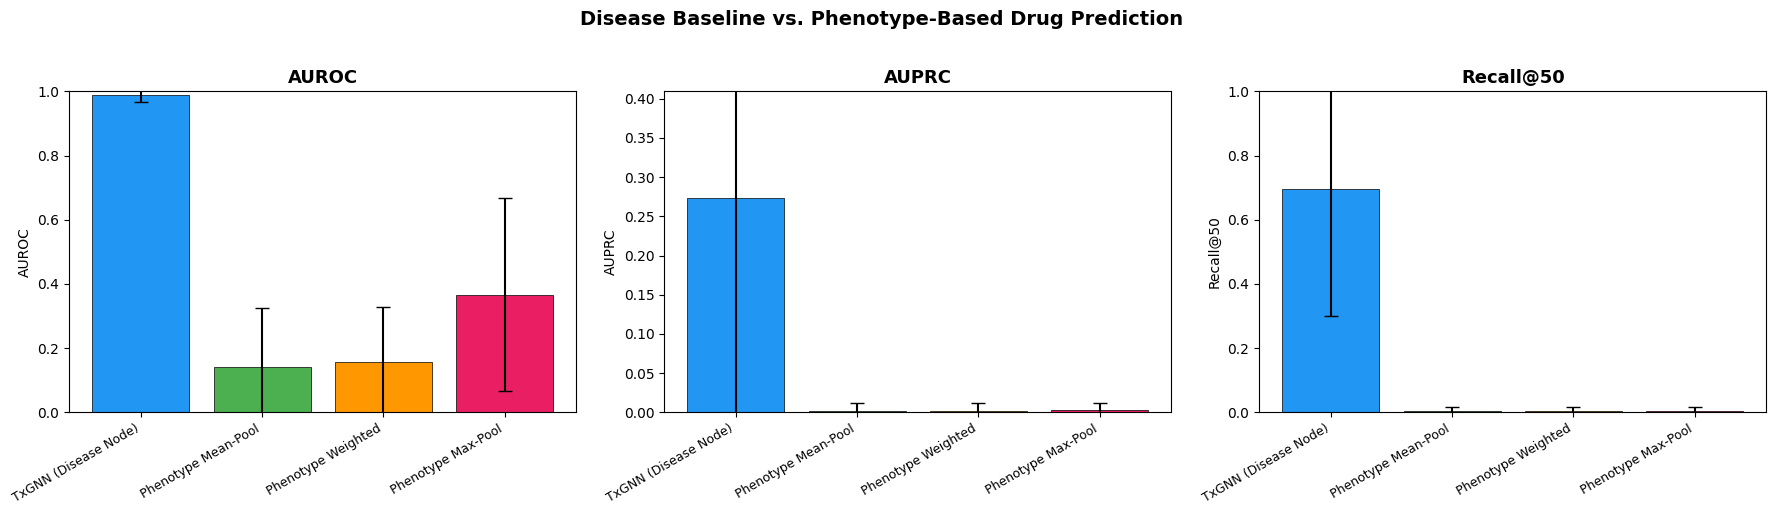

In [34]:
# ── Bar chart comparison ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_metrics = ['AUROC', 'AUPRC', 'Recall@50']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for ax, metric in zip(axes, plot_metrics):
    means = [pd.DataFrame(all_results[m])[metric].mean() for m in methods]
    stds = [pd.DataFrame(all_results[m])[metric].std() for m in methods]
    bars = ax.bar(range(len(methods)), means, yerr=stds, color=colors, 
                  capsize=5, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels([method_labels[m] for m in methods], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(metric)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, min(1.0, max(means) * 1.5))

plt.suptitle('Disease Baseline vs. Phenotype-Based Drug Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()